Appraisal file exists: True
WS bonus file exists: True

Raw shape: (2832, 40)

Columns:
['Region Name', 'Store Name', 'Apprsl Type', 'Unseen Flag', 'Vehicle Src', 'Curr Status Id', 'Status Name', 'Apprsl Date', 'Acquired Date', 'Stock No', 'Vin', 'Year', 'Std Make', 'Std Model', 'Trim', 'Mileage', 'Apprsl Value', 'Acquired Value', 'Est Recon', 'Rtc Recom Price', 'Retail Price', 'Model Price', 'Wsale Avg', 'Bad Carfax Flag', 'Drivetrain', 'Extr Color', 'Intr Color', 'Intr Type', 'Transmission', 'Engine', 'Fuel', 'Cylinders', 'Sold Date', 'Rtc Specialist', 'App Submitter', 'Exp Guide', 'Sac Notes', 'Rtc Notes', 'Manager Notes', 'Row Count - Custom Query']

Shape after cleanup: (2832, 40)

Purchased rate: 0.5643

Channel distribution:
Channel
Other      1710
Website    1122
Name: count, dtype: int64

Sample engineered columns:
                 Vin  Purchased  Channel  Apprsl Value  Wsale Avg  \
0  JN1CF0BB7PM707130          1    Other       20732.0    19150.0   
1  3FA6P0HD7JR200829      

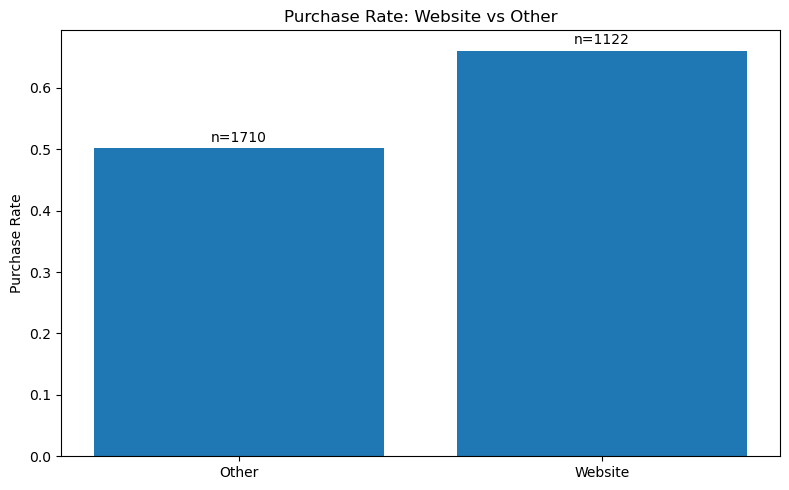


Mileage band counts:
mileage_band
0-50k        492
50k-80k      516
80k-120k     898
120k-200k    778
200k+        148
Name: count, dtype: int64


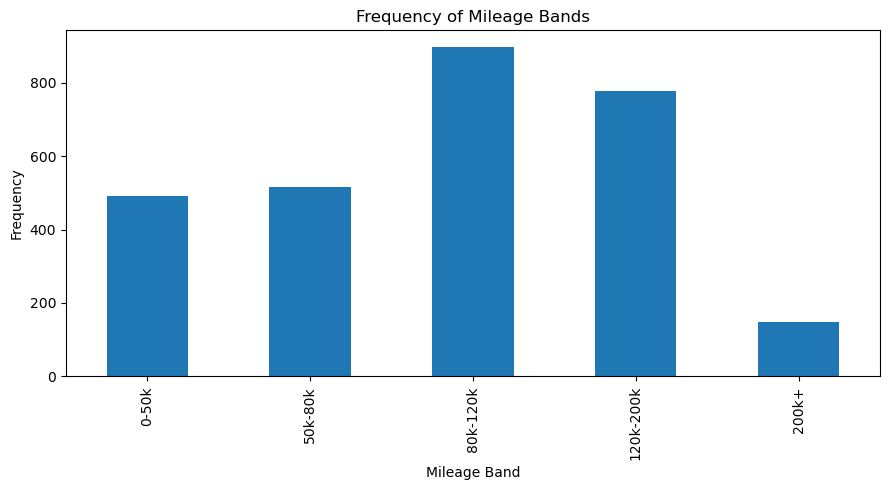


Purchase rate by offer-minus-wholesale bucket:
offer_minus_wsale_bucket
(-inf, -5000.0]       0.338798
(-5000.0, -2500.0]    0.477941
(-2500.0, -1000.0]    0.511494
(-1000.0, 0.0]        0.621795
(0.0, 1000.0]         0.652866
(1000.0, 2500.0]      0.706840
(2500.0, 5000.0]      0.758730
(5000.0, inf]         0.784431
Name: Purchased, dtype: float64


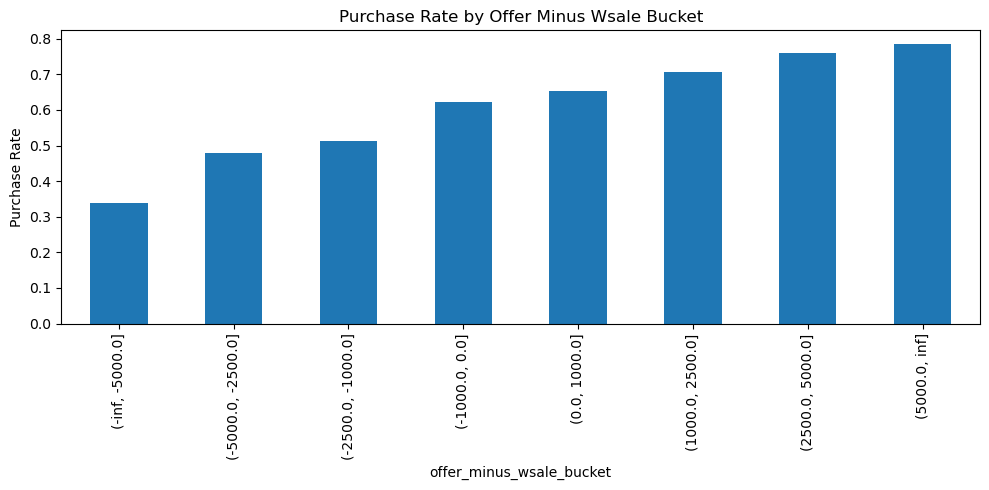


Model dataset shape: (2607, 56)
Target rate: 0.5715
Numeric features: ['Apprsl Value', 'Mileage', 'Year', 'vehicle_age', 'Wsale Avg', 'Rtc Recom Price', 'Model Price', 'Est Recon', 'Bad Carfax Flag', 'Unseen Flag', 'offer_minus_wsale', 'offer_minus_model', 'offer_minus_rtc', 'appr_month', 'appr_weekday']
Categorical features: ['Channel', 'Region Name', 'Store Name', 'Apprsl Type', 'Std Make', 'Std Model', 'Trim', 'Drivetrain', 'Transmission', 'Fuel', 'mileage_band']

Train shape: (2085, 26)
Test shape: (522, 26)

Fitting logistic_regression...

Fitting random_forest...

Model comparison:
                 model  accuracy  precision    recall        f1   roc_auc
1        random_forest  0.900383   0.918367  0.906040  0.912162  0.952930
0  logistic_regression  0.722222   0.752475  0.765101  0.758735  0.787542

Best model: random_forest

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       224
           1       0.9

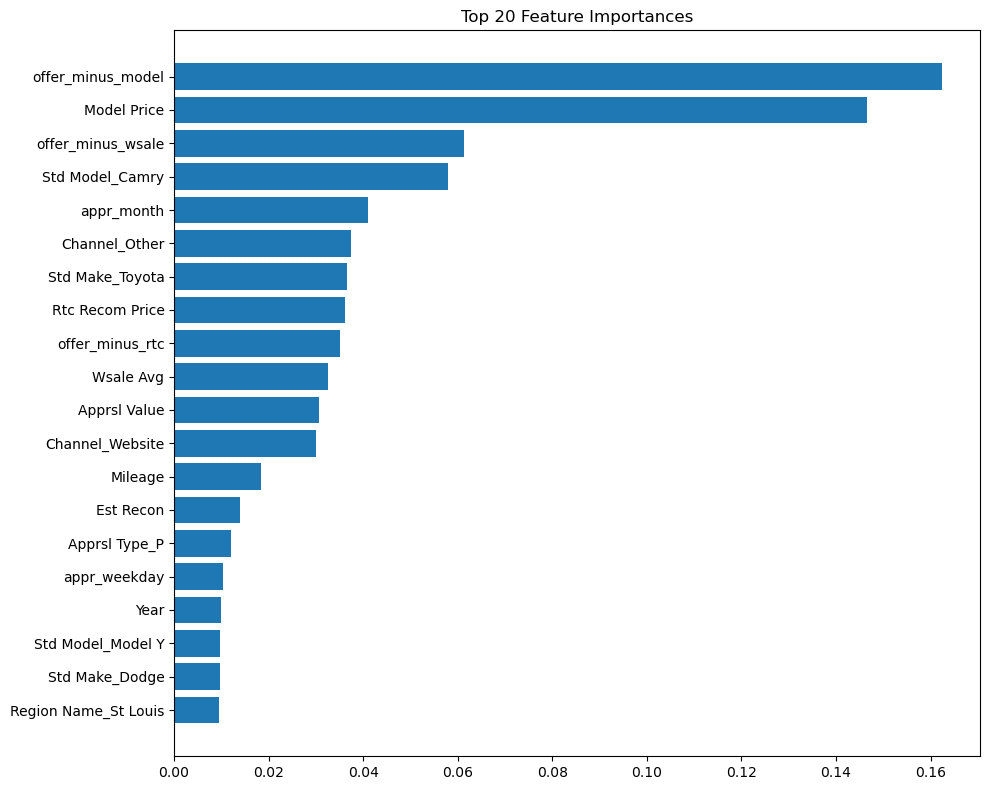

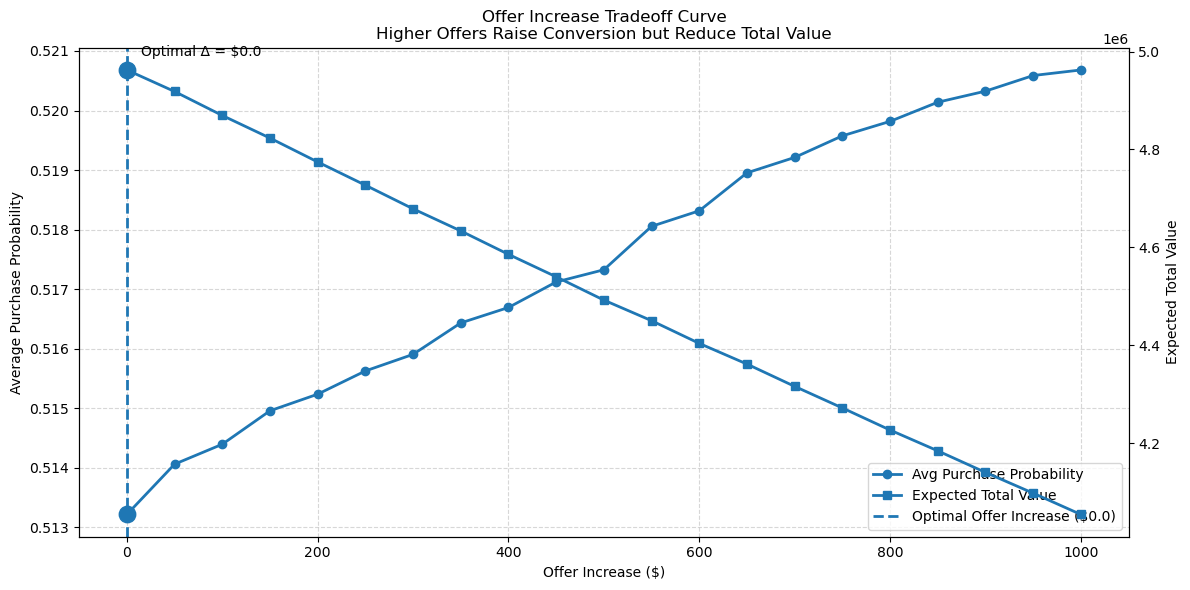

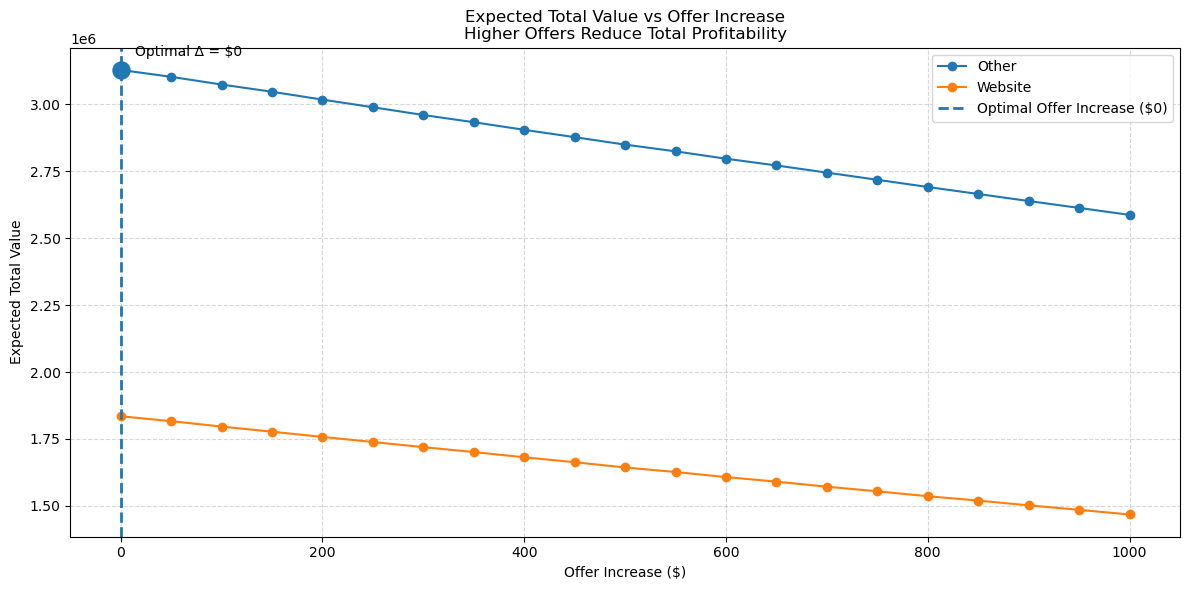


Wholesale/bonus VIN overlap: 0
No VIN overlap found.

Done.
Outputs saved to: /Users/jimmyduncan/Desktop/School/DSC680/vehicle_acquisition_outputs


In [1]:
# ============================================================
# VEHICLE ACQUISITION MODEL 
# Jimmy Duncan - DSC680
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# 1. FILE PATHS
# ============================================================

# Put these files in the SAME folder as your notebook/script
APPRAISAL_FILE = Path("EPAppraisalReport-MTD (28).xlsx")
APPRAISAL_SHEET = "Appraisal Data"

WS_BONUS_FILE = Path("26_4_1_WS_Bonus_Data.xlsx")
WS_BONUS_SHEET = "Sheet2"

OUTPUT_DIR = Path("vehicle_acquisition_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Appraisal file exists:", APPRAISAL_FILE.exists())
print("WS bonus file exists:", WS_BONUS_FILE.exists())


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_excel(APPRAISAL_FILE, sheet_name=APPRAISAL_SHEET, engine="openpyxl")

print("\nRaw shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 3. BASIC CLEANING
# ============================================================

# Standardize column names
df.columns = [str(c).strip().replace("\n", " ") for c in df.columns]

# Clean key text columns
for col in ["Vin", "Stock No", "Status Name", "Exp Guide"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

# Force VIN/Stock to uppercase
for col in ["Vin", "Stock No"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper()
        df[col] = df[col].replace({"NAN": np.nan, "NONE": np.nan, "": np.nan})

# Convert dates
date_cols = ["Apprsl Date", "Acquired Date", "Sold Date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Numeric columns
numeric_cols_expected = [
    "Year", "Mileage", "Apprsl Value", "Acquired Value", "Est Recon",
    "Rtc Recom Price", "Retail Price", "Model Price", "Wsale Avg",
    "Bad Carfax Flag", "Cylinders", "Vehicle Src", "Curr Status Id",
    "Unseen Flag"
]

for col in numeric_cols_expected:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop duplicates
df = df.drop_duplicates()

# Keep rows with VIN if available
if "Vin" in df.columns:
    df = df[df["Vin"].notna()].copy()

print("\nShape after cleanup:", df.shape)


# ============================================================
# 4. TARGET VARIABLE
# ============================================================

acquired_statuses = {
    "IN-STOCK",
    "RECON ECHOPARK",
    "INBOUND ECHOPARK",
    "SOLD WHOLESALE",
    "STORE PURCHASE",
    "WHOLESALE",
    "PENDING DELIVERY",
    "OUTBOUND GROUP TRADE"
}

status_upper = df["Status Name"].astype(str).str.upper().str.strip() if "Status Name" in df.columns else pd.Series("", index=df.index)

stock_exists = df["Stock No"].notna() if "Stock No" in df.columns else pd.Series(False, index=df.index)
acq_date_exists = df["Acquired Date"].notna() if "Acquired Date" in df.columns else pd.Series(False, index=df.index)
acq_value_exists = df["Acquired Value"].notna() if "Acquired Value" in df.columns else pd.Series(False, index=df.index)

df["Purchased"] = np.where(
    stock_exists | acq_date_exists | acq_value_exists | status_upper.isin(acquired_statuses),
    1,
    0
)

print("\nPurchased rate:", round(df["Purchased"].mean(), 4))


# ============================================================
# 5. CHANNEL VARIABLE
# ============================================================

if "Exp Guide" in df.columns:
    df["Channel"] = np.where(
        df["Exp Guide"].astype(str).str.upper().str.strip().eq("WEBSITE"),
        "Website",
        "Other"
    )
else:
    df["Channel"] = "Other"

print("\nChannel distribution:")
print(df["Channel"].value_counts(dropna=False))


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

def safe_divide(numerator, denominator):
    return np.where(
        denominator.notna() & (denominator != 0),
        numerator / denominator,
        np.nan
    )

# Core spread features
if {"Apprsl Value", "Wsale Avg"}.issubset(df.columns):
    df["offer_minus_wsale"] = df["Apprsl Value"] - df["Wsale Avg"]
    df["offer_to_wsale_ratio"] = safe_divide(df["Apprsl Value"], df["Wsale Avg"])
else:
    df["offer_minus_wsale"] = np.nan
    df["offer_to_wsale_ratio"] = np.nan

if {"Apprsl Value", "Model Price"}.issubset(df.columns):
    df["offer_minus_model"] = df["Apprsl Value"] - df["Model Price"]
    df["offer_to_model_ratio"] = safe_divide(df["Apprsl Value"], df["Model Price"])
else:
    df["offer_minus_model"] = np.nan
    df["offer_to_model_ratio"] = np.nan

if {"Apprsl Value", "Rtc Recom Price"}.issubset(df.columns):
    df["offer_minus_rtc"] = df["Apprsl Value"] - df["Rtc Recom Price"]
    df["offer_to_rtc_ratio"] = safe_divide(df["Apprsl Value"], df["Rtc Recom Price"])
else:
    df["offer_minus_rtc"] = np.nan
    df["offer_to_rtc_ratio"] = np.nan

if {"Acquired Value", "Wsale Avg"}.issubset(df.columns):
    df["acquired_minus_wsale"] = df["Acquired Value"] - df["Wsale Avg"]
else:
    df["acquired_minus_wsale"] = np.nan

# Vehicle age
if "Year" in df.columns:
    current_year = pd.Timestamp.today().year
    df["vehicle_age"] = current_year - df["Year"]
else:
    df["vehicle_age"] = np.nan

# Mileage bands
if "Mileage" in df.columns:
    df["mileage_band"] = pd.cut(
        df["Mileage"],
        bins=[-np.inf, 50000, 80000, 120000, 200000, np.inf],
        labels=["0-50k", "50k-80k", "80k-120k", "120k-200k", "200k+"]
    )
else:
    df["mileage_band"] = np.nan

# Missing-offer flag
if "Apprsl Value" in df.columns:
    df["missing_offer_flag"] = df["Apprsl Value"].isna().astype(int)
else:
    df["missing_offer_flag"] = 1

# Days to acquire
if {"Acquired Date", "Apprsl Date"}.issubset(df.columns):
    df["days_to_acquire"] = (df["Acquired Date"] - df["Apprsl Date"]).dt.days
else:
    df["days_to_acquire"] = np.nan

# Date features
if "Apprsl Date" in df.columns:
    df["appr_month"] = df["Apprsl Date"].dt.month
    df["appr_weekday"] = df["Apprsl Date"].dt.dayofweek
else:
    df["appr_month"] = np.nan
    df["appr_weekday"] = np.nan

# Unseen Flag cleanup
if "Unseen Flag" in df.columns:
    df["Unseen Flag"] = pd.to_numeric(df["Unseen Flag"], errors="coerce").fillna(0)
else:
    df["Unseen Flag"] = 0

# Replace inf everywhere
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Clip extreme outliers
for col in ["Apprsl Value", "Wsale Avg", "Rtc Recom Price", "Model Price", "Mileage"]:
    if col in df.columns and df[col].notna().sum() > 0:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)

print("\nSample engineered columns:")
sample_cols = [
    "Vin", "Purchased", "Channel", "Apprsl Value", "Wsale Avg",
    "offer_minus_wsale", "offer_to_wsale_ratio", "mileage_band"
]
sample_cols = [c for c in sample_cols if c in df.columns]
print(df[sample_cols].head())


# ============================================================
# 7. EDA
# ============================================================

# Purchase rate by channel
purchase_by_channel = df.groupby("Channel")["Purchased"].agg(["mean", "count"]).reset_index()
print("\nPurchase rate by channel:")
print(purchase_by_channel)

plt.figure(figsize=(8, 5))
plt.bar(purchase_by_channel["Channel"], purchase_by_channel["mean"])
plt.title("Purchase Rate: Website vs Other")
plt.ylabel("Purchase Rate")
for i, row in purchase_by_channel.iterrows():
    plt.text(i, row["mean"] + 0.01, f"n={int(row['count'])}", ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "purchase_rate_by_channel.png", dpi=200)
plt.show()

# Mileage band frequency
if "mileage_band" in df.columns:
    mileage_counts = df["mileage_band"].value_counts(dropna=False).sort_index()
    print("\nMileage band counts:")
    print(mileage_counts)

    plt.figure(figsize=(9, 5))
    mileage_counts.plot(kind="bar")
    plt.title("Frequency of Mileage Bands")
    plt.xlabel("Mileage Band")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "mileage_band_frequency.png", dpi=200)
    plt.show()

# Purchase rate by offer spread bucket
if "offer_minus_wsale" in df.columns:
    df["offer_minus_wsale_bucket"] = pd.cut(
        df["offer_minus_wsale"],
        bins=[-np.inf, -5000, -2500, -1000, 0, 1000, 2500, 5000, np.inf]
    )

    spread_purchase = df.groupby("offer_minus_wsale_bucket", observed=False)["Purchased"].mean()
    print("\nPurchase rate by offer-minus-wholesale bucket:")
    print(spread_purchase)

    plt.figure(figsize=(10, 5))
    spread_purchase.plot(kind="bar")
    plt.title("Purchase Rate by Offer Minus Wsale Bucket")
    plt.ylabel("Purchase Rate")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "purchase_rate_by_offer_minus_wsale_bucket.png", dpi=200)
    plt.show()


# ============================================================
# 8. MODEL DATASET
# ============================================================

model_df = df.copy()

required_cols = ["Apprsl Value", "Year", "Mileage", "Channel"]
for col in required_cols:
    if col in model_df.columns:
        model_df = model_df[model_df[col].notna()]

# Safer feature set
feature_cols_num = [
    "Apprsl Value",
    "Mileage",
    "Year",
    "vehicle_age",
    "Wsale Avg",
    "Rtc Recom Price",
    "Model Price",
    "Est Recon",
    "Bad Carfax Flag",
    "Unseen Flag",
    "offer_minus_wsale",
    "offer_minus_model",
    "offer_minus_rtc",
    "appr_month",
    "appr_weekday",
]

feature_cols_cat = [
    "Channel",
    "Region Name",
    "Store Name",
    "Apprsl Type",
    "Std Make",
    "Std Model",
    "Trim",
    "Drivetrain",
    "Transmission",
    "Fuel",
    "mileage_band"
]

feature_cols_num = [c for c in feature_cols_num if c in model_df.columns]
feature_cols_cat = [c for c in feature_cols_cat if c in model_df.columns]

X = model_df[feature_cols_num + feature_cols_cat].copy()
y = model_df["Purchased"].copy()

# Clean X again before modeling
X.replace([np.inf, -np.inf], np.nan, inplace=True)

print("\nModel dataset shape:", model_df.shape)
print("Target rate:", round(y.mean(), 4))
print("Numeric features:", feature_cols_num)
print("Categorical features:", feature_cols_cat)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


# ============================================================
# 9. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols_num),
        ("cat", categorical_transformer, feature_cols_cat)
    ]
)


# ============================================================
# 10. MODELS
# ============================================================

models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    )
}

results = []
fitted_pipelines = {}

for model_name, model in models.items():
    print(f"\nFitting {model_name}...")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    results.append(row)

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
print("\nModel comparison:")
print(results_df)

results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)


# ============================================================
# 11. BEST MODEL REVIEW
# ============================================================

best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]

print(f"\nBest model: {best_model_name}")

best_pred = best_pipe.predict(X_test)
best_prob = best_pipe.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, best_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, best_pred))


# ============================================================
# 12. FEATURE IMPORTANCE (RANDOM FOREST ONLY)
# ============================================================

def get_feature_names(preprocessor_obj, num_cols, cat_cols):
    num_features = num_cols
    ohe = preprocessor_obj.named_transformers_["cat"].named_steps["onehot"]
    cat_features = list(ohe.get_feature_names_out(cat_cols))
    return num_features + cat_features

if best_model_name == "random_forest":
    feature_names = get_feature_names(
        best_pipe.named_steps["preprocessor"],
        feature_cols_num,
        feature_cols_cat
    )

    importances = best_pipe.named_steps["model"].feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\nTop 25 feature importances:")
    print(importance_df.head(25))

    importance_df.to_csv(OUTPUT_DIR / "feature_importances.csv", index=False)

    plt.figure(figsize=(10, 8))
    top_plot = importance_df.head(20).sort_values("importance")
    plt.barh(top_plot["feature"], top_plot["importance"])
    plt.title("Top 20 Feature Importances")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_feature_importances.png", dpi=200)
    plt.show()


# ============================================================
# 13. SIMULATION ENGINE
# ============================================================

simulation_base = model_df.copy()
simulation_results = []

for delta in range(0, 1001, 50):
    sim = simulation_base.copy()

    sim["sim_offer"] = sim["Apprsl Value"] + delta
    sim["Apprsl Value"] = sim["sim_offer"]

    # Rebuild engineered features safely
    if {"Apprsl Value", "Wsale Avg"}.issubset(sim.columns):
        sim["offer_minus_wsale"] = sim["Apprsl Value"] - sim["Wsale Avg"]
    else:
        sim["offer_minus_wsale"] = np.nan

    if {"Apprsl Value", "Model Price"}.issubset(sim.columns):
        sim["offer_minus_model"] = sim["Apprsl Value"] - sim["Model Price"]
    else:
        sim["offer_minus_model"] = np.nan

    if {"Apprsl Value", "Rtc Recom Price"}.issubset(sim.columns):
        sim["offer_minus_rtc"] = sim["Apprsl Value"] - sim["Rtc Recom Price"]
    else:
        sim["offer_minus_rtc"] = np.nan

    sim.replace([np.inf, -np.inf], np.nan, inplace=True)

    sim_X = sim[feature_cols_num + feature_cols_cat].copy()
    sim_X.replace([np.inf, -np.inf], np.nan, inplace=True)

    sim["pred_purchase_prob"] = best_pipe.predict_proba(sim_X)[:, 1]

    # Simple EV framework
    model_price = sim["Model Price"] if "Model Price" in sim.columns else np.nan
    wsale_avg = sim["Wsale Avg"] if "Wsale Avg" in sim.columns else np.nan
    est_recon = sim["Est Recon"] if "Est Recon" in sim.columns else 0

    reference_value = pd.Series(
        np.where(pd.notna(model_price), model_price, wsale_avg),
        index=sim.index
    )

    est_recon = pd.Series(est_recon, index=sim.index) if np.isscalar(est_recon) else est_recon

    sim["expected_front_margin"] = (
        reference_value.fillna(0)
        - sim["Apprsl Value"].fillna(0)
        - est_recon.fillna(0)
    ).clip(lower=0)

    assumed_backend_gross = 1200
    sim["expected_total_margin"] = sim["expected_front_margin"] + assumed_backend_gross
    sim["expected_value"] = sim["pred_purchase_prob"] * sim["expected_total_margin"]

    simulation_results.append({
        "offer_delta": delta,
        "avg_predicted_purchase_prob": sim["pred_purchase_prob"].mean(),
        "expected_total_margin_per_unit": sim["expected_total_margin"].mean(),
        "avg_expected_value": sim["expected_value"].mean(),
        "expected_total_value_all_rows": sim["expected_value"].sum()
    })

simulation_df = pd.DataFrame(simulation_results)

# ============================================================
# EXECUTIVE TRADEOFF CURVE
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: probability
line1 = ax1.plot(
    simulation_df["offer_delta"],
    simulation_df["avg_predicted_purchase_prob"],
    marker="o",
    linewidth=2,
    label="Avg Purchase Probability"
)
ax1.set_xlabel("Offer Increase ($)")
ax1.set_ylabel("Average Purchase Probability")
ax1.tick_params(axis="y")

# Right axis: expected total value
ax2 = ax1.twinx()
line2 = ax2.plot(
    simulation_df["offer_delta"],
    simulation_df["expected_total_value_all_rows"],
    marker="s",
    linewidth=2,
    label="Expected Total Value"
)
ax2.set_ylabel("Expected Total Value")
ax2.tick_params(axis="y")

# Optimal point based on expected total value
best_row = simulation_df.loc[
    simulation_df["expected_total_value_all_rows"].idxmax()
]

best_delta = best_row["offer_delta"]
best_value = best_row["expected_total_value_all_rows"]
best_prob = best_row["avg_predicted_purchase_prob"]

# Vertical line at optimum
ax1.axvline(
    x=best_delta,
    linestyle="--",
    linewidth=2,
    label=f"Optimal Offer Increase (${best_delta})"
)

# Highlight best points
ax1.scatter(best_delta, best_prob, s=140, zorder=5)
ax2.scatter(best_delta, best_value, s=140, zorder=5)

# Annotation
ax2.annotate(
    f"Optimal Δ = ${best_delta}",
    (best_delta, best_value),
    textcoords="offset points",
    xytext=(10, 10)
)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
labels.append(f"Optimal Offer Increase (${best_delta})")

# Need one handle for the vline
vline_handle = plt.Line2D([0], [0], linestyle="--", linewidth=2)
handles = lines + [vline_handle]

plt.title(
    "Offer Increase Tradeoff Curve\n"
    "Higher Offers Raise Conversion but Reduce Total Value"
)

ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(handles, labels, loc="best")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "EXECUTIVE_tradeoff_curve.png", dpi=300)
plt.show()


# ============================================================
# 14. CHANNEL-SPECIFIC SIMULATION
# ============================================================

channel_sim_results = []

for channel_name in ["Website", "Other"]:
    channel_base = model_df[model_df["Channel"] == channel_name].copy()

    if channel_base.empty:
        continue

    for delta in range(0, 1001, 50):
        sim = channel_base.copy()

        sim["sim_offer"] = sim["Apprsl Value"] + delta
        sim["Apprsl Value"] = sim["sim_offer"]

        if {"Apprsl Value", "Wsale Avg"}.issubset(sim.columns):
            sim["offer_minus_wsale"] = sim["Apprsl Value"] - sim["Wsale Avg"]
        else:
            sim["offer_minus_wsale"] = np.nan

        if {"Apprsl Value", "Model Price"}.issubset(sim.columns):
            sim["offer_minus_model"] = sim["Apprsl Value"] - sim["Model Price"]
        else:
            sim["offer_minus_model"] = np.nan

        if {"Apprsl Value", "Rtc Recom Price"}.issubset(sim.columns):
            sim["offer_minus_rtc"] = sim["Apprsl Value"] - sim["Rtc Recom Price"]
        else:
            sim["offer_minus_rtc"] = np.nan

        sim.replace([np.inf, -np.inf], np.nan, inplace=True)

        sim_X = sim[feature_cols_num + feature_cols_cat].copy()
        sim_X.replace([np.inf, -np.inf], np.nan, inplace=True)

        sim["pred_purchase_prob"] = best_pipe.predict_proba(sim_X)[:, 1]

        model_price = sim["Model Price"] if "Model Price" in sim.columns else np.nan
        wsale_avg = sim["Wsale Avg"] if "Wsale Avg" in sim.columns else np.nan
        est_recon = sim["Est Recon"] if "Est Recon" in sim.columns else 0

        reference_value = pd.Series(
            np.where(pd.notna(model_price), model_price, wsale_avg),
            index=sim.index
        )

        est_recon = pd.Series(est_recon, index=sim.index) if np.isscalar(est_recon) else est_recon

        sim["expected_front_margin"] = (
            reference_value.fillna(0)
            - sim["Apprsl Value"].fillna(0)
            - est_recon.fillna(0)
        ).clip(lower=0)

        assumed_backend_gross = 1200
        sim["expected_total_margin"] = sim["expected_front_margin"] + assumed_backend_gross
        sim["expected_value"] = sim["pred_purchase_prob"] * sim["expected_total_margin"]

        channel_sim_results.append({
            "channel": channel_name,
            "offer_delta": delta,
            "avg_predicted_purchase_prob": sim["pred_purchase_prob"].mean(),
            "expected_total_value_all_rows": sim["expected_value"].sum()
        })

channel_sim_df = pd.DataFrame(channel_sim_results)
channel_sim_df.to_csv(OUTPUT_DIR / "channel_offer_simulation_results.csv", index=False)

plt.figure(figsize=(12, 6))

for channel_name, sub in channel_sim_df.groupby("channel"):
    plt.plot(
        sub["offer_delta"],
        sub["expected_total_value_all_rows"],
        marker="o",
        label=channel_name
    )

best_row = channel_sim_df.loc[
    channel_sim_df["expected_total_value_all_rows"].idxmax()
]

best_delta = best_row["offer_delta"]
best_value = best_row["expected_total_value_all_rows"]

plt.axvline(
    x=best_delta,
    linestyle="--",
    linewidth=2,
    label=f"Optimal Offer Increase (${best_delta})"
)

plt.scatter(best_delta, best_value, s=150)

plt.annotate(
    f"Optimal Δ = ${best_delta}",
    (best_delta, best_value),
    textcoords="offset points",
    xytext=(10,10)
)

plt.title(
    "Expected Total Value vs Offer Increase\n"
    "Higher Offers Reduce Total Profitability"
)

plt.xlabel("Offer Increase ($)")
plt.ylabel("Expected Total Value")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "EXECUTIVE_channel_value_curve.png", dpi=300)
plt.show()


# ============================================================
# 15. OPTIONAL WHOLESALE / BONUS MERGE
# ============================================================

try:
    if WS_BONUS_FILE.exists():
        ws = pd.read_excel(WS_BONUS_FILE, sheet_name=WS_BONUS_SHEET, engine="openpyxl")
        ws.columns = [str(c).strip().replace("\n", " ") for c in ws.columns]

        if "Vin" in ws.columns and "Vin" in df.columns:
            ws["Vin"] = ws["Vin"].astype(str).str.strip().str.upper()

            overlap = set(df["Vin"].dropna()).intersection(set(ws["Vin"].dropna()))
            print(f"\nWholesale/bonus VIN overlap: {len(overlap)}")

            if len(overlap) > 0:
                keep_cols = [c for c in ["Vin", "Gross", "Selling Source", "Week", "Stk Type"] if c in ws.columns]

                merged_ws = df.merge(ws[keep_cols], on="Vin", how="left")
                merged_ws.to_csv(OUTPUT_DIR / "appraisal_plus_ws_bonus.csv", index=False)
                print("Saved merged appraisal + WS file.")
            else:
                print("No VIN overlap found.")
except Exception as e:
    print("\nCould not process WS bonus file:", e)


# ============================================================
# 16. SAVE MODEL-READY DATA
# ============================================================

model_df.to_csv(OUTPUT_DIR / "model_ready_appraisal_data.csv", index=False)

print("\nDone.")
print(f"Outputs saved to: {OUTPUT_DIR.resolve()}")